# Inhibition in Enzyme Kinetics

Inhibition is one of biology's fundamental "brake" mechanisms: without it, biochemical and signalling networks would tend to drift towards saturation or runaway activity. But inhibition is rarely *just* a brake. When it is **nonlinear** — when the strength of inhibition depends nonlinearly on the concentration of an inhibitor — it can produce behaviours that a simple linear or Hill model never could: sharp thresholds that allow switching between distinct stable states (**bistability**, or more generally **multistability**).

This notebook explores bistability, using a single enzymatic reaction as a worked example. A later notebook starts from this kinetics and builds more complex dynamics by adding more features. 

## Where nonlinear inhibition comes from

In biochemistry, inhibition is usually introduced on top of Michaelis–Menten kinetics: an inhibitor (I) alters the reaction rate (v) at which a substrate (S) is converted into product.

**Competitive inhibition.** The substrate and inhibitor compete for the same active site on the enzyme (E), so the inhibitor effectively reduces the amount of free enzyme available:

$$v = \frac{V_{max}[S]}{K_m\left(1 + \frac{[I]}{K_i}\right) + [S]}$$

If enough substrate is added ($[S]\to\infty$), the inhibitor's effect is overwhelmed and $v \to V_{max}$ — only the *apparent* $K_m$ increases.

**Allosteric (cooperative) inhibition.** The inhibitor binds a different site, changing the enzyme's shape so that it stops working regardless of how much substrate is present. When several inhibitor molecules bind cooperatively, this is described by a **Hill function**:

$$v = V_{max}\cdot \frac{K_i^n}{K_i^n + [I]^n}$$

where $n$ is the Hill coefficient. Plotting this for $n=1$ gives a smooth, hyperbolic decline; for $n=4$ it becomes sigmoidal — a "switch-like" curve where the enzyme stays fully active until a threshold inhibitor concentration is reached, at which point activity collapses sharply. This switch-like, nonlinear shape is the key ingredient for everything that follows in this notebook.

## Nonlinear inhibition in gene regulatory networks

The same Hill-type nonlinearity appears when one gene product represses another. If gene A inhibits gene B, and gene B inhibits gene A (mutual inhibition), the result can be a **bistable switch**: the system settles into one of two states — (high A, low B) or (low A, high B)  — and stays there. This is one of the simplest models for binary cell-fate decisions, such as commitment to one of two possible cell types during development.

## Nonlinearity elsewhere in biology

The same basic idea — a nonlinear, threshold-like inhibitory interaction — recurs across very different biological systems: in neural circuits, mutual inhibition between excitatory and inhibitory populations can generate brain-wave oscillations or sharp transitions between resting and active states; in ecology, competing species inhibit each other's growth through shared resources, with nonlinear competition terms determining whether the populations coexist or one excludes the other. The table below summarises the pattern:

| **Domain** | **Activator/Driver** | **Inhibitor** | **Common Mathematical Tool** |
| --- | --- | --- | --- |
| **Biochemistry** | Substrate (S) | Allosteric Molecule (I) | Michaelis–Menten / Hill Equation |
| **Genetics** | Transcription Factor | Repressor Protein | Sigmoidal Production Terms |
| **Neuroscience** | Glutamate / Pyramidal Cells | GABA / Interneurons | Wilson–Cowan (Sigmoid Firing Rates) |
| **Ecology** | Resource Birth Rate (r) | Competitor Species ($\alpha_{ij}$) | Lotka–Volterra Competition Terms |

In every row, the underlying mathematics is the same: a negative term that scales with the inhibitor's concentration, passed through a nonlinear (often sigmoidal) function. The rest of this notebook works through one concrete case — forward inhibition in an enzymatic reaction — in enough detail to see exactly how that nonlinearity gives rise to multistability.

# Substrate Inhibition

**Substrate inhibition** (or substrate self-regulation) is a classic example of non-monotonic, nonlinear behaviour in biochemical networks. In standard Michaelis–Menten kinetics, adding more substrate always increases the reaction velocity until it plateaus at $V_{max}$. But when a substrate can bind to *both* a catalytic site and a separate regulatory (inhibitory) site on the same enzyme, the velocity curve climbs to a peak and then **falls again** as substrate concentration increases further.

## The two-site model

Take a kinase that uses ATP as its substrate. The enzyme has two distinct binding pockets for ATP:

1. **The catalytic site** (high affinity, low capacity): binds ATP easily even at low concentrations and drives the forward (phosphorylation) reaction.
2. **The allosteric/regulatory site** (low affinity): only fills up when ATP concentrations are high. When ATP binds here, it triggers a conformational change that shuts down the catalytic site.

Schematically:

```
        + S (Fast)               + S (Slow / At High [S])
   E  <=========>  ES --------> E + P     <==========>   ESS (Inactive)
       (Catalytic)    (Catalytic)         (Inhibitory)
```

where E is the free enzyme, ES is the active complex producing product P, and ESS is the dead-end, inactive complex formed when a second substrate molecule occupies the regulatory site.

## The Haldane equation

Applying a steady-state (or quasi-equilibrium) assumption to this scheme gives the standard equation for substrate inhibition, sometimes called the **Haldane equation**:

$$v = \frac{V_{max}[S]}{K_m + [S] + \frac{[S]^2}{K_i}}$$

where $K_m$ is the dissociation constant for the catalytic site and $K_i$ is the dissociation constant for the inhibitory site.

- **At low substrate concentration** ($[S] \ll K_i$): the $[S]^2/K_i$ term is negligible, and the equation collapses to ordinary Michaelis–Menten kinetics, $v \approx \dfrac{V_{max}[S]}{K_m + [S]}$.
- **At high substrate concentration** ($[S] \gg K_m$): the $[S]^2/K_i$ term dominates the denominator, so $v \approx \dfrac{V_{max} K_i}{[S]}$ — the rate *decreases* as $[S]$ increases.

## A bell-shaped, non-monotonic curve

The defining feature of substrate inhibition is that $v$ vs $[S]$ is **bell-shaped** rather than a saturating hyperbola. Differentiating $v$ with respect to $[S]$ and setting $dv/d[S]=0$ shows that the peak velocity occurs at

$$[S]_{opt} = \sqrt{K_m \cdot K_i}$$

A natural computational exercise is to find $[S]_{opt}$ and the corresponding peak velocity numerically and check this relation.

## Why would biology do this?

It may seem strange for an enzyme to "turn itself off" when its substrate is abundant, but this is a powerful regulatory strategy:

- **Overload protection.** For ATP-sensitive kinases, if ATP rises to dangerously high levels, substrate inhibition forces a slowdown of high-energy pathways, helping maintain metabolic balance.
- **Bistability and thresholding.** Combined with a downstream removal process (e.g. a phosphatase), substrate inhibition can create a **bistable toggle**: the system can sit in either a highly active or a fully dormant state, with little in between. This is the phenomenon explored in the rest of this notebook.
- **Pacemaking.** In a metabolic loop, substrate inhibition can cause the substrate concentration to spontaneously oscillate — the topic of notebook *03_enzyme_oscillations*.

# Code
## Simple Inhibition Function

Here is how an inhibitor impacts on an otherwise constant reaction rate. 

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def inhibitory_kinetics(I, k_max, K_m, m):
    """
    Inhibitory kinetics controlled by an exponent
    I: inhibitor concentration
    k_max: maximum reaction rate
    K_m: Michaelis constant
    m: inhibition coefficient
    """
    rate = k_max / (K_m + I**m)

    return rate

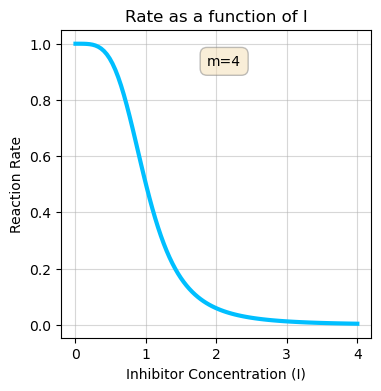

In [30]:
# Constants
K_m   = 1
k_max = 1
m     = 4 # inhibition coefficient 

# Range of substrate values
I_min, I_max = 0, 4
values = 100
I_vals = np.linspace(I_min, I_max, values)

# Calculation of the rate for all values of S
rate = inhibitory_kinetics(I_vals, k_max, K_m, m)


# --- Plot 1: line plots of fucntion ---
fig, ax1 = plt.subplots(figsize=(4, 4))

ax1.plot(I_vals, rate, color='deepskyblue', linewidth=3)
# ax1.vlines(1, 0, k_max, 'gray', linestyles='dotted')
# ax1.hlines(k_max/2, 0, I_max, 'gray', linestyles='dashed')

ax1.set_xlabel('Inhibitor Concentration (I)')
ax1.set_ylabel('Reaction Rate')
ax1.set_title('Rate as a function of I')
ax1.grid(True, alpha=0.5)


# Textbox 1
textstr = f'm={m}'

# Define the style of the textbox using a dictionary
props = dict(
    boxstyle='round,pad=0.5', 
    facecolor='wheat', 
    alpha=0.5, 
    edgecolor='gray'
)

# Place the text box in the upper left of the axes
ax1.text(
    0.47, 0.92, textstr, 
    transform=ax1.transAxes, 
    fontsize=10,
    verticalalignment='top', 
    bbox=props
);


In [ ]:
For $m=1$, the rate decreases hyperbolically with the amount of inhibitor. With $m=4$, the function becomes sigmoidal. At first the rate stays high, then suddenly drops, and finally stays near zero, i.e. at very low rates. It is an inverse form of the Hill function. The larger $m$, the more pronounced the "switching off" behaviour. 


## Forward Inhibition Function

A special case of inhibition is substrate or forward inhibition as discussed above. In this case, the substrate of the reaction itself becomes an inhibitor of the type just discussed. 

A famous example is the PFK1 reaction in yeast glycolysis where $ATP$ as one of its substrates shows pronounced forward inhibition. 

A simple and flexible version of the Haldane equation has this function:

$$rate = \frac{k_{max}[S]^n}{K_m + [S]^m}$$

It is similar to the Hill function except that the singel Hill exponent is now split into two exponents which can be handled independently. In such a case, where there is a variable with an exponent in both numerator and denominator, the rule is that the larger of the two will always win. When $n>m$, the rate will go towards **infinity** as $S$ is increased. When $n<m$, the rate will go towards **zero** as $S$ is increased. 

## Forward Inhibition Function with Sliders

As in the case of the Hill function we can explore the shape of the forward inhibition interactively. Use different combinations of the two exponents to understand their interplay. 

In [7]:
from numpy import linspace
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider, VBox
import plotly.graph_objects as go

def kinetics(S, k_max, K_m, n, m):
    """
    Hill kinetics equation; reduces to Michaelis-Menten for n=1
    S: substrate concentration
    k_max: maximum reaction rate (includes enzyme concentration)
    K_m: Michaelis constant (fixed at 1)
    n: Hill exponent
    m: inhibition exponent (n<=m)
    """
    rate = (k_max * S**n) / (K_m + S**m)
    return rate

# Fixed parameters
k_max, K_m = 2, 1
# x-axis grid: substrate concentration from 0 to 4
S_values = linspace(0, 10, 100)

# Create the interactive plot
def plot_kinetics(n, m):
    """Update plot based on slider values"""
    # Evaluate the rate equation for every S in S_values, for the current (n, m)
    rate_curve = kinetics(S_values, k_max, K_m, n, m)
    
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=S_values,
        y=rate_curve,
        mode='lines',
        line=dict(color='red', width=4),
        name=f'n={n:.2f}, m={m:.2f}'
    ))
    
    fig.update_layout(
        title=dict(
            text=f"Forward Inhibition Kinetics<br><sub>n (Hill) = {n:.2f}, m (Haldane) = {m:.2f}</sub>",
            x=0.5
        ),
        xaxis=dict(title="Substrate Concentration (S)", range=[-0.1, S_values[-1]+0.1]),
        yaxis=dict(title="Reaction Rate", range=[-0.1, 3.5]),
        width=700,
        height=600,
        showlegend=False
    )
    
    fig.show()

# Create sliders with ipywidgets.
# n controls the cooperativity of activation (Hill exponent);
# m controls how strongly the enzyme is inhibited at high S (Haldane/inhibition exponent).
# Try n=1, m=1 first (plain Michaelis-Menten), then increase m to see the
# rate curve turn from monotonic into the bell-shaped, non-monotonic
# "substrate inhibition" curve discussed above.
interact(
    plot_kinetics,
    n=FloatSlider(
        value=1.0,
        min=1.0,
        max=5.0,
        step=0.1,
        description='n (Hill):',
        continuous_update=False,  # Only update when slider is released
        style={'description_width': '100px'}
    ),
    m=FloatSlider(
        value=1.0,
        min=0.5,
        max=4.0,
        step=0.1,
        description='m (Haldane):',
        continuous_update=False,
        style={'description_width': '100px'}
    )
);

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='n (Hill):', max=5.0, min=1.…

When both $n$ and $m$ are equal, we have the combined Michaelis-Menten-Hill rate. When $n$ is larger than $m$, the rate increases without bounds –- an unlikely case in biochemistry. When $m$ is larger than $n$, there is an initial increase, a maximal rate and after that a asymptotic decline towards zero. Substrate or forward inhibition is thus both activating (for small concentrations) and inhibiting at the same time. In the initial, activating part of the function, the rise is hyperbolic when $n=1$ and sigmoidal when $n$ is larger than one. The dependence on two coefficients thus allows to model rather complex rate functions. 

An overview of the overall dependence can be obtained by studying a two-dimensional extenstion of the rate function. 

## Rate Surface

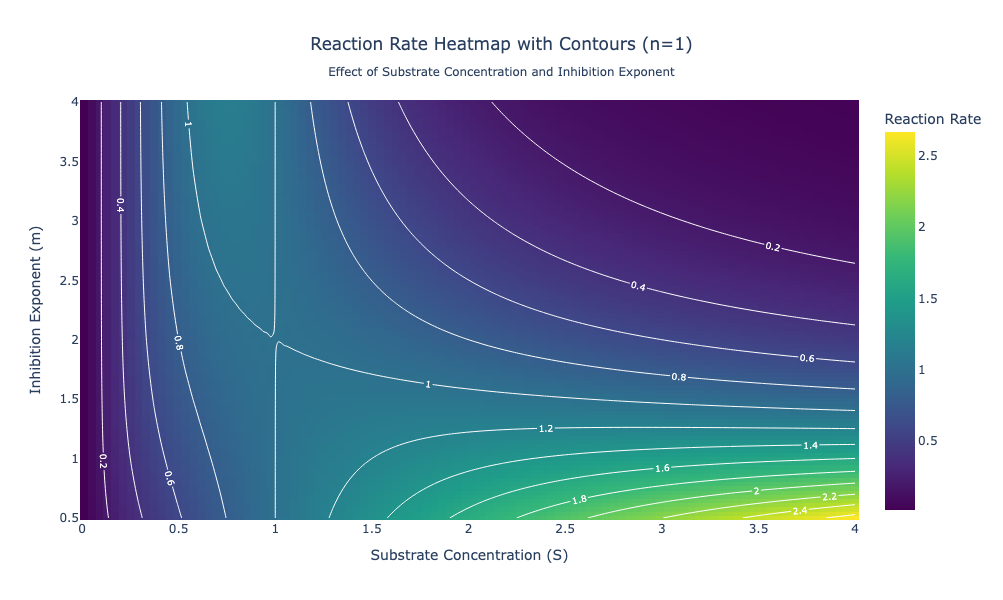

In [8]:
from numpy import linspace, meshgrid
import plotly.graph_objects as go

def kinetics(S, k_max, K_m, n, m):
    """
    Hill kinetics equation; reduces to Michaelis-Menten for n=1
    S: substrate concentration
    k_max: maximum reaction rate (includes enzyme concentration)
    K_m: Michaelis constant (fixed at 1)
    n: Hill exponent
    m: inhibition exponent (n<=m)
    """
    rate = (k_max * S**n) / (K_m + S**m)
    return rate

# Fixed parameters: cooperativity n is fixed at 1 (plain Michaelis-Menten
# activation), so the only thing that varies below is the inhibition
# exponent m.
k_max, K_m, n = 2, 1, 1

# Create 2D grid
S_values = linspace(0.01, 4, 100)  # Start slightly above 0 to avoid division issues
m_values = linspace(0.5, 4, 100)

# Create meshgrid: S_grid and m_grid have matching shapes so that
# kinetics() can be evaluated for every (S, m) combination at once.
S_grid, m_grid = meshgrid(S_values, m_values)

# Calculate rate for all combinations
rate_grid = kinetics(S_grid, k_max, K_m, n, m_grid)

# Combine heatmap with contour lines
fig = go.Figure()

# Add heatmap: colour encodes the reaction rate for each (S, m) pair
fig.add_trace(go.Heatmap(
    x=S_values,
    y=m_values,
    z=rate_grid,
    colorscale='Viridis',
    colorbar=dict(title="Reaction Rate"),
    hoverongaps=False,
    showscale=True
))

# Add contour lines on top, to make lines of equal rate easier to read
fig.add_trace(go.Contour(
    x=S_values,
    y=m_values,
    z=rate_grid,
    showscale=False,
    contours=dict(
        showlabels=True,
        labelfont=dict(size=9, color='white'),
        coloring='none'
    ),
    line=dict(width=1, color='white'),
    hoverinfo='skip'
))

fig.update_layout(
    title=dict(
        text="Reaction Rate Heatmap with Contours (n=1)<br><sub>Effect of Substrate Concentration and Inhibition Exponent</sub>",
        x=0.5
    ),
    xaxis=dict(title="Substrate Concentration (S)"),
    yaxis=dict(title="Inhibition Exponent (m)"),
    width=700,
    height=600
)

fig.show()

Note the yellow region where the function goes to infinity ($n$ > $m$). The light-blue region near $S=1$ is where the maximal rate can be found. The contour lines show one point where the rate increases along both $m$ directions, but decreases along both $S$ directions. Such a point is called a *saddle*.

For better intuitive understanding, here is an interactive surface plot of the same data. 

## 3D Rate Surface Plot 

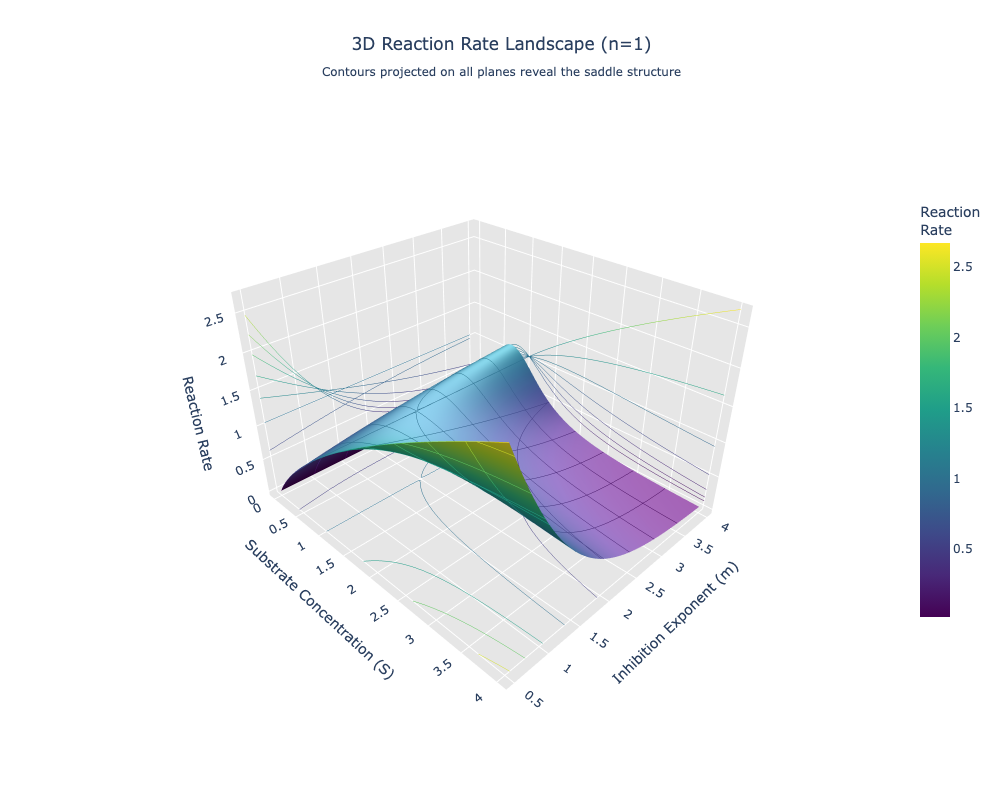

In [9]:
from numpy import linspace, meshgrid
import plotly.graph_objects as go

def kinetics(S, k_max, K_m, n, m):
    """
    Hill kinetics equation; reduces to Michaelis-Menten for n=1
    S: substrate concentration
    k_max: maximum reaction rate (includes enzyme concentration)
    K_m: Michaelis constant (fixed at 1)
    n: Hill exponent
    m: inhibition exponent (n<=m)
    """
    rate = (k_max * S**n) / (K_m + S**m)
    return rate

# Fixed parameters
k_max, K_m, n = 2, 1, 1

# Create 2D grid
S_values = linspace(0.01, 4, 100)  # Start slightly above 0
m_values = linspace(0.5, 4, 100)

# Create meshgrid
S_grid, m_grid = meshgrid(S_values, m_values)

# Calculate rate for all combinations
rate_grid = kinetics(S_grid, k_max, K_m, n, m_grid)

# Create 3D surface with contours projected on all three planes.
# This is the same data as the heatmap above, but drawn as a literal
# "rate landscape": height = reaction rate, the two horizontal axes are
# substrate concentration S and inhibition exponent m.
fig = go.Figure(data=[go.Surface(
    x=S_values,
    y=m_values,
    z=rate_grid,
    colorscale='Viridis',
    colorbar=dict(title="Reaction<br>Rate", len=0.7),
    hovertemplate='S: %{x:.2f}<br>m: %{y:.2f}<br>Rate: %{z:.2f}<extra></extra>',
    lighting=dict(
        ambient=0.6,
        diffuse=0.8,
        specular=0.3,
        roughness=0.5
    ),
    contours=dict(
        x=dict(show=True, usecolormap=True, highlightcolor="white", project=dict(x=True)),
        y=dict(show=True, usecolormap=True, highlightcolor="white", project=dict(y=True)),
        z=dict(show=True, usecolormap=True, highlightcolor="white", project=dict(z=True))
    )
)])

fig.update_layout(
    title=dict(
        text="3D Reaction Rate Landscape (n=1)<br><sub>Contours projected on all planes reveal the saddle structure</sub>",
        x=0.5
    ),
    scene=dict(
        xaxis=dict(title="Substrate Concentration (S)", backgroundcolor="rgb(230, 230,230)"),
        yaxis=dict(title="Inhibition Exponent (m)", backgroundcolor="rgb(230, 230,230)"),
        zaxis=dict(title="Reaction Rate", backgroundcolor="rgb(230, 230,230)"),
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=1.3)  # Initial viewing angle
        )
    ),
    width=900,
    height=800
)

fig.show()

# Code
## Bistability in Open Flow

So far we have looked at how the reaction *rate* depends on substrate or inhibitor concentration. The key finding was that multiple binding sites — cooperativity for activation, plus a separate inhibitory site(s) as in the Haldane model — make the rate curve strongly nonlinear and even non-monotonic as in the substrate-inhibition curve from the previous section.

The next question is: what happens when this nonlinear reaction is embedded in an **open system**, with a continuous supply (influx) and removal (outflow/dilution) of substrate? Such "open flow" settings are the norm in living cells, which constantly exchange material with their environment. Our model is inspired by the PFK1 (phosphofructokinase-1) reaction in glycolysis, where ATP acts both as substrate and (via regulatory sites) as inhibitor.

### Why multistability matters

When the inflow/outflow balance is combined with forward inhibition, something new can happen: for the *same* parameter values, the system can have **more than one** stable steady state. This is **multistability** (with two stable states, **bistability**). Why is this biologically important?

- **Decision-making.** A bistable system can interpret a graded input (e.g. a hormone or signalling molecule concentration) as a binary output: "low" or "high". This is the basic building block of cellular decisions such as commitment to differentiation, cell-cycle progression, or apoptosis.
- **Memory.** Once a bistable system has switched to one state, it tends to *stay there* even if the input that caused the switch goes away again — a simple form of cellular memory, related to the phenomenon of **hysteresis** (the system's response depends on its history, not just its current input).
- **Robust thresholds.** Because the two stable states are separated by an unstable state acting as a threshold, small fluctuations (noise) are filtered out: the system only switches when a perturbation is large enough to cross the threshold.

### Plan for this section

We will:

1. Reduce the full two-variable model to a single equation for S (decoupling it from the product P), and simulate its time course for two different values of the input parameter $a_1$ (cells below).
2. Find **all** steady states of this equation and classify each as stable or unstable, then scan over $a_1$ to build a **bifurcation diagram** — a map of how the number and position of steady states changes with $a_1$.
3. Turn the steady-state structure into a 1D **potential landscape** $V(S)$ — the "ball rolling in a landscape" picture, where stable states are valleys and unstable states are the hills between them.
4. Finally, extend this into a 2D landscape as $a_1$ varies continuously — reproducing, in a simple quantitative model, Waddington's classic "epigenetic landscape" picture of development.

In [10]:
# solve_ivp: numerical ODE integrator, used below to simulate S(t)
from scipy.integrate import solve_ivp
# subplots: matplotlib helper for creating figure/axes grids
# from matplotlib.pyplot import subplots
# # linspace: evenly spaced sample points; around/var/ndarray: small numeric
# # helpers used in later analysis cells
# from numpy import linspace, around, var, ndarray
# # find_peaks: detect local maxima in a time series (useful for spotting
# # oscillations - kept here for consistency with notebook 03)
# from scipy.signal import find_peaks

## Feedforward inhibition in Open Flow

The cell below defines a variant of our  model: a single ODE for the substrate $S$, with constant influx, linear removal, and the same forward-inhibition kinetics used for the rate surfaces above. This is the "open flow" system referred to in the introduction to this section.

Here is the mathematical notation:

$$ rate = k_{max} \cdot S^n /( K_m + S^m)$$
$$ \frac{dS}{dt}  = a_s - b_s \cdot S - rate$$
$$ \frac{dP}{dt}  = a_p - b_p \cdot P + rate$$

Compared to the open flow model with Hill kinetics, the only change is that the exponent in the numerator and the denominator are not identical anymore. 

This simple change allows a qualitatively new dynamic feature to appear in the model. It is the simplest case of a self-organised behaviour that only happens when the model is not only nonlinear but has the specific type of nonlinearity which we just introduced. 

Here is the model function followed by the code to use the function for integration. 

In [15]:
def model(t, S, a_s, b_s, k_max, K_m, n, m):
    """Enzymatic Reaction with forward inhibition

    This is a 1-variable reduction of the 2-variable model used in
    the notebook on enzymatic oscillations: here we track only the substrate S
    and ignore the downstream product P because it is not having an effect on the rate. This is a simplifying assumption, not necessarily the reality. a2 and b2 are accepted as
    arguments (so the function signature matches the 2-variable version)
    but are not used in the right-hand side below.

    t    : time (unused, but required by solve_ivp's function signature)
    S    : current substrate concentration
    a1   : constant input/production rate of S (the "control parameter"
           we vary throughout this notebook)
    b1   : linear removal rate of S (e.g. dilution, degradation)
    k_max, K_m, n, m : Hill/Haldane kinetics parameters, as in the
           kinetics() function above (forward inhibition: m > n)
    """

    # Nonlinear consumption of S by the enzyme, including forward
    # (substrate) inhibition at high S - same functional form as
    # kinetics(S, k_max, K_m, n, m) used earlier for the rate surfaces.
    enzymatic_rate = (k_max * S**n) / (K_m + S**m)

    # Net rate of change of S: constant inflow (a1), linear outflow
    # (b1 * S), minus the nonlinear enzymatic consumption.
    dSdt = a_s - b_s * S - enzymatic_rate

    return dSdt

## Time Series

We know that the amount of substrate provided via the (cosntant) influx term regulates the steady state that is reached. The below simulations test how the steady state changes for two different values of influx $a_s$ is reached from the same starting condition.

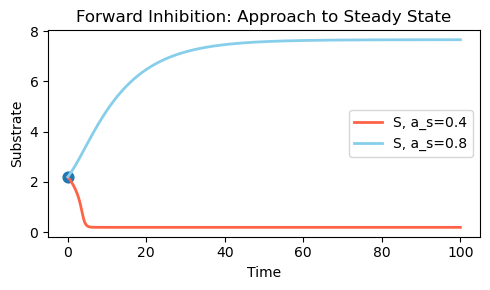

In [21]:
# Two values of the input/production rate a1 to compare: a "low" value
# and a "high" value. We will see that they lead to qualitatively
# different long-term behaviour of S.
a_s_pars  = [0.4, 0.8]

b_s        = 0.1
k_max, K_m = 2, 1
n, m       = 1, 3   # m > n: forward (substrate) inhibition is active

# Initial condition: both simulations start from the same S(0)
S_0 = [2.2]

t_span = (0, 100)


fig, ax = plt.subplots(figsize=(5, 3))

colors = ['tomato', 'skyblue']

# Run one simulation per value of a1 and plot S(t) for each
for index, a_s in enumerate(a_s_pars):

    solution = solve_ivp(model, t_span, S_0, args=(a_s, b_s, k_max, K_m, n, m), method='BDF', max_step=0.1)
    
    t = solution.t
    
    S = solution.y.T
        
    ax.plot(t, S, label=f'S, a_s={a_s}', linewidth=2, color=colors[index])

ax.scatter(0, S_0, marker='o', s=60)
ax.set_xlabel('Time')
ax.set_ylabel('Substrate')
ax.legend()
# Both curves approach a steady value (no oscillation here - that is the
# subject of notebook 03). With the same starting point S_0=2.2, the two
# values of a1 lead to very different final levels of S - a first hint of
# the bistability analysed in detail below.
ax.set_title('Forward Inhibition: Approach to Steady State')



fig.tight_layout()

### From a single trajectory to a bifurcation diagram

The two trajectories above start from the *same* initial condition ($S_0 = 2.2$) but use different values of $a_s$, and end up at very different long-term values of $S$ (one low, one high). This already hints that the long-term behaviour depends sensitively on $a_s$ — but a single simulation per parameter value cannot tell us how the steady state depends on that value of $a_s$. This is again asking for a function but this time a dynamic function: we want to see how the final steady state depends on $a_s$.

To address that we expand our analysis. A steady state is any value $S^*$ for which $dS/dt = 0$; we find these by solving $f(S) = a_s - b_s S - \text{(enzymatic rate)} = 0$ numerically from many different starting guesses (cell below), and then classify each $S^*$ as **stable** or **unstable** by checking the sign of $df/dS$ at that point.

Repeating this for a whole range of $a_s$ values produces a **bifurcation diagram**: a plot of steady-state value $S^*$ against the control parameter $a_s$, showing how many steady states exist and how their stability changes. Wherever the *number* of steady states changes, we have crossed a **bifurcation point** — and, as we will see, this is exactly where bistability appears or disappears, and where **hysteresis** (history-dependent switching) becomes possible.

## Analysis of Bistability

This section carries out the plan from the introduction. The code below works with the reduced, one-variable equation

$$\frac{dS}{dt} = a_1 - b_1 S - \frac{k_{max}S^n}{K_m + S^m}$$

(the same right-hand side as `model()` above, without the unused `a2`, `b2` arguments). For this single equation, `find_steady_states_1D` locates every root $S^*$, `check_stability_1D` determines whether each root is stable or unstable, `compute_potential_1D` turns the equation into a potential landscape $V(S)$, and the two plotting functions visualise the results as (i) a bifurcation diagram over a range of $a_1$, and (ii) a side-by-side comparison of the phase portrait and potential for $a_1=0.4$ and $a_1=0.8$.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import cumulative_trapezoid

def dS_dt(S, a1, b1, k_max, K_m, n, m):
    """First equation only - S dynamics independent of P"""
    enzymatic_rate = (k_max * S**n) / (K_m**m + S**m)
    return a1 - b1 * S - enzymatic_rate

def find_steady_states_1D(a1, b1, k_max, K_m, n, m):
    """Find steady states for S equation.

    A steady state S* satisfies dS/dt = 0, i.e. dS_dt(S*, ...) = 0.
    Because dS_dt is nonlinear there is no closed-form solution, so we
    search for roots numerically with fsolve, starting from many
    different initial guesses S_guess spread across the plausible range
    of S. This gives fsolve a chance to find *every* root, not just the
    one nearest to a single starting point. Converged roots are checked
    (positive, residual close to zero) and de-duplicated so that the same
    steady state is not counted twice.
    """
    steady_states = []
    
    # Try multiple initial guesses
    for S_guess in np.linspace(0.1, 15, 50):
        try:
            sol = fsolve(lambda S: dS_dt(S, a1, b1, k_max, K_m, n, m), 
                        S_guess, full_output=True)
            if sol[2] == 1:  # Converged
                S_star = sol[0][0]
                if S_star > 0:  # Positive solution
                    residual = abs(dS_dt(S_star, a1, b1, k_max, K_m, n, m))
                    if residual < 1e-8:
                        # Check if new
                        is_new = True
                        for existing in steady_states:
                            if abs(S_star - existing) < 1e-4:
                                is_new = False
                                break
                        if is_new:
                            steady_states.append(S_star)
        except:
            pass
    
    return sorted(steady_states)

def check_stability_1D(S_star, a1, b1, k_max, K_m, n, m, epsilon=1e-6):
    """Check stability by examining the derivative of dS/dt at the steady state.

    Near a steady state S*, dS/dt ~ f'(S*) * (S - S*). If f'(S*) < 0, any
    small displacement decays back towards S* (stable, a "valley"); if
    f'(S*) > 0, displacements grow (unstable, a "hilltop"). f'(S*) is
    approximated here with a central finite difference.
    """
    # Compute df/dS at steady state
    f_plus = dS_dt(S_star + epsilon, a1, b1, k_max, K_m, n, m)
    f_minus = dS_dt(S_star - epsilon, a1, b1, k_max, K_m, n, m)
    derivative = (f_plus - f_minus) / (2 * epsilon)
    
    # Stable if derivative < 0
    is_stable = derivative < 0
    
    return is_stable, derivative

def compute_potential_1D(a1, b1, k_max, K_m, n, m, S_range=(0.1, 10), resolution=1000):
    """
    Compute 1D potential V(S) such that dS/dt = -dV/dS.

    For a single ODE, dS/dt = f(S) can always be written as the negative
    gradient of a potential V(S): integrating -f(S) over S gives V(S), up
    to an arbitrary additive constant. Stable steady states (f'(S*) < 0)
    become minima ("valleys") of V, and unstable steady states become
    maxima ("hilltops"/barriers) - the "ball rolling in a landscape"
    picture used throughout this notebook.
    """
    S_array = np.linspace(S_range[0], S_range[1], resolution)
    
    # Compute dS/dt for all S values
    dS_dt_array = np.array([dS_dt(S, a1, b1, k_max, K_m, n, m) for S in S_array])
    
    # Integrate to get potential: V(S) = -∫ (dS/dt) dS
    potential = cumulative_trapezoid(-dS_dt_array, S_array, initial=0)
    
    # Shift so minimum is at zero (V is only defined up to an additive
    # constant, so this is purely for a convenient y-axis)
    potential = potential - np.min(potential)
    
    return S_array, potential, dS_dt_array

def plot_1D_potential_comparison():
    """Plot 1D potential for both a1 values side by side.

    Top row: phase portrait dS/dt vs S - where the curve crosses zero are
    the steady states, and the sign of dS/dt on either side shows which
    way S moves.
    Bottom row: the corresponding potential V(S) - the same information
    redrawn as a landscape (valleys = stable, hilltops = unstable).
    """
    
    # Parameters
    b1 = 0.1
    k_max, K_m = 2, 1
    n, m = 1, 3
    a1_values = [0.4, 0.8]
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    
    colors_stable = ['red', 'blue', 'green']
    colors_unstable = ['orange']
    
    for idx, a1 in enumerate(a1_values):
        # Find steady states
        steady_states = find_steady_states_1D(a1, b1, k_max, K_m, n, m)
        
        print(f"\n{'='*50}")
        print(f"a1 = {a1}")
        print(f"{'='*50}")
        print(f"Found {len(steady_states)} steady state(s):")
        
        stable_states = []
        unstable_states = []
        
        for i, S_star in enumerate(steady_states):
            is_stable, derivative = check_stability_1D(S_star, a1, b1, k_max, K_m, n, m)
            stability = "STABLE" if is_stable else "UNSTABLE"
            print(f"  S* = {S_star:.6f}  [{stability}]  (df/dS = {derivative:.6f})")
            
            if is_stable:
                stable_states.append(S_star)
            else:
                unstable_states.append(S_star)


        
        # Compute potential and force
        S_array, potential, force = compute_potential_1D(a1, b1, k_max, K_m, n, m)

        # Top row: Phase portrait (dS/dt vs S)
        ax_phase = axes[0, idx]
        ax_phase.plot(S_array, force, 'g-', linewidth=2.5, label='dS/dt')
        ax_phase.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax_phase.fill_between(S_array, 0, force, where=(force > 0), 
                             alpha=0.3, color='blue', label='S increases')
        ax_phase.fill_between(S_array, 0, force, where=(force < 0), 
                             alpha=0.3, color='red', label='S decreases')
        
        # Mark stable steady states
        for i, S_star in enumerate(stable_states):
            ax_phase.plot(S_star, 0, 'o', color='red', markersize=15,
                         markeredgecolor='white', markeredgewidth=2.5, zorder=5)
            # Add arrows showing stability
            ax_phase.annotate('', xy=(S_star, 0), xytext=(S_star - 0.3, 0),
                            arrowprops=dict(arrowstyle='->', color='red', lw=2))
            ax_phase.annotate('', xy=(S_star, 0), xytext=(S_star + 0.3, 0),
                            arrowprops=dict(arrowstyle='->', color='red', lw=2))
        
        # Mark unstable steady states
        for i, S_star in enumerate(unstable_states):
            ax_phase.plot(S_star, 0, 'X', color='cyan', markersize=15,
                         markeredgecolor='white', markeredgewidth=2.5, zorder=5)
            # Add arrows showing instability
            ax_phase.annotate('', xy=(S_star - 0.3, 0), xytext=(S_star, 0),
                            arrowprops=dict(arrowstyle='->', color='orange', lw=2))
            ax_phase.annotate('', xy=(S_star + 0.3, 0), xytext=(S_star, 0),
                            arrowprops=dict(arrowstyle='->', color='orange', lw=2))
        
        ax_phase.set_xlabel('S (Substrate)', fontsize=12, fontweight='bold')
        ax_phase.set_ylabel('dS/dt (Rate)', fontsize=12, fontweight='bold')
        ax_phase.set_title(f'Phase Portrait (a1={a1})', fontsize=13, fontweight='bold')
        ax_phase.legend(loc='best', fontsize=9)
        ax_phase.grid(True, alpha=0.3)

        
        
        # Bottom row: Potential V(S)
        ax_pot = axes[1, idx]
        ax_pot.plot(S_array, potential, 'b-', linewidth=2.5, label='V(S)')
        ax_pot.fill_between(S_array, 0, potential, alpha=0.3)
        
        # Mark stable steady states on potential
        for i, S_star in enumerate(stable_states):
            V_star = np.interp(S_star, S_array, potential)
            ax_pot.plot(S_star, V_star, 'o', color='red', markersize=15,
                       markeredgecolor='white', markeredgewidth=2.5,
                       label=f'Stable: S*={S_star:.3f}', zorder=5)
        
        # Mark unstable steady states on potential
        for i, S_star in enumerate(unstable_states):
            V_star = np.interp(S_star, S_array, potential)
            ax_pot.plot(S_star, V_star, 'X', color='cyan', markersize=15,
                       markeredgecolor='white', markeredgewidth=2.5,
                       label=f'Unstable: S*={S_star:.3f}', zorder=5)
        
        ax_pot.set_xlabel('S (Substrate)', fontsize=12, fontweight='bold')
        ax_pot.set_ylabel('Potential V(S)', fontsize=12, fontweight='bold')
        ax_pot.set_title(f'Potential Landscape (a1={a1})', fontsize=13, fontweight='bold')
        ax_pot.legend(loc='best', fontsize=9)
        ax_pot.grid(True, alpha=0.3)
        ax_pot.set_ylim(bottom=-0.1)
    
    
    plt.tight_layout()
    # plt.savefig('potential_1D_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_combined_bifurcation(n, m):
    """Plot bifurcation diagram showing the transition from monostable to bistable.

    Repeats the steady-state + stability analysis above for a whole range
    of a1 values, then plots S* against a1. Stable branches (red dots) and
    the unstable branch (cyan crosses) trace out the bifurcation diagram;
    wherever a branch appears or disappears marks a bifurcation point.
    """
    
    b1 = 0.1
    k_max, K_m = 2, 1
    
    # Scan a1 values
    a1_values = np.linspace(0.3, 1.5, 100)
    
    all_stable = []
    all_unstable = []
    all_a1_stable = []
    all_a1_unstable = []
    
    for a1 in a1_values:
        steady_states = find_steady_states_1D(a1, b1, k_max, K_m, n, m)
        
        for S_star in steady_states:
            is_stable, _ = check_stability_1D(S_star, a1, b1, k_max, K_m, n, m)
            
            if is_stable:
                all_stable.append(S_star)
                all_a1_stable.append(a1)
            else:
                all_unstable.append(S_star)
                all_a1_unstable.append(a1)
    
    # Plot bifurcation diagram
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    if all_a1_stable:
        ax.plot(all_a1_stable, all_stable, 'o', color='red', 
               markersize=3, label='Stable steady states', alpha=0.7)
    if all_a1_unstable:
    # if all_a1_unstable and (m>2):
        ax.plot(all_a1_unstable, all_unstable, 'x', color='cyan', 
               markersize=4, label='Unstable steady state', alpha=0.7)
    
    ax.axvline(x=0.4, color='gray', linestyle='--', linewidth=2, 
              alpha=0.5, label='a1=0.4')
    ax.axvline(x=0.8, color='black', linestyle='--', linewidth=2, 
              alpha=0.5, label='a1=0.8')
 
    ax.set_xlabel('a1 (control parameter)', fontsize=12, fontweight='bold')
    ax.set_ylabel('S* (steady state)', fontsize=12, fontweight='bold')
    ax.set_title('Bifurcation Diagram: Saddle-Node Bifurcation', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Textbox 1
    textstr = f'n={n}, m={m}'
    
    # Define the style of the textbox using a dictionary
    props = dict(
        boxstyle='round,pad=0.5', 
        facecolor='wheat', 
        alpha=0.5, 
        edgecolor='gray'
    )
    
    # Place the text box in the upper left of the axes
    ax.text(
        0.37, 0.92, textstr, 
        transform=ax.transAxes, 
        fontsize=10,
        verticalalignment='top', 
        bbox=props
    );
    
    plt.tight_layout()
    # plt.savefig('bifurcation_diagram_1D.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the analysis
print("="*37)
print("|| 1D POTENTIAL LANDSCAPE ANALYSIS ||")
print("="*37)

|| 1D POTENTIAL LANDSCAPE ANALYSIS ||


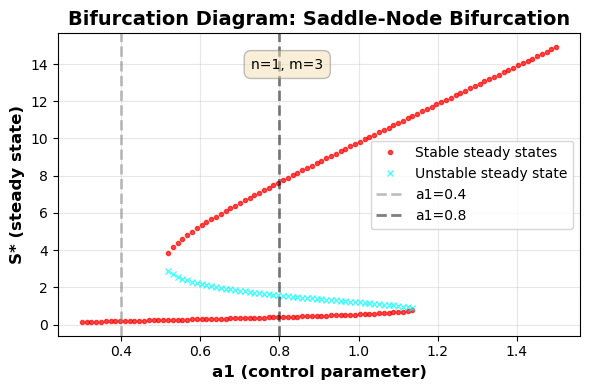

In [24]:
# Generate the bifurcation diagram defined above: S* vs a1, with the
# stable branches in red and the unstable branch in cyan. See the markdown
# cell below for how to read this plot.
n, m = 1, 3

plot_combined_bifurcation(n, m)


### Reading the bifurcation diagram: $n=1, m=3$

Running the scan over $a_1 \in [0.3, 1.5]$ shows three regimes:

- For $a_1 \lesssim 0.51$, there is a **single stable steady state** at low $S$ (e.g. at $a_1=0.4$, $S^*\approx0.19$). This matches the "low" trajectory in the time-series plot above.
- Just above $a_1\approx0.51$, a pair of new steady states — one stable, one unstable — appears via a **saddle-node bifurcation**. From this point until $a_1\approx1.15$, the system has **three** steady states: a low stable state, a middle *unstable* state, and a high stable state. This is the bistable regime (e.g. at $a_1=0.8$: $S^*\approx0.41$ stable, $S^*\approx1.57$ unstable, $S^*\approx7.66$ stable).
- Above $a_1\approx1.15$, the low stable branch and the unstable branch collide and annihilate in a second saddle-node bifurcation, leaving only the **high** stable steady state.

This structure is exactly what produces **hysteresis**. Imagine starting on the low branch and slowly increasing $a_1$: the system tracks the low branch smoothly until $a_1\approx1.15$, where that branch disappears and the system is forced to jump up to the high branch. Now slowly *decrease* $a_1$ again: the system stays on the high branch (which still exists) all the way down to $a_1\approx0.51$, where it disappears and the system jumps back down to the low branch. The "switch-up" and "switch-down" happen at *different* values of $a_1$ — the system's state depends on which direction it was driven from, i.e. on its history. This history-dependence is the hallmark of a bistable switch with memory, and it is the simplest dynamical mechanism underlying many biological decision-making circuits.

## Potential and Phase Portrait

Because the reduced model is a single ODE, $dS/dt = f(S)$ can always be written as $f(S) = -\dfrac{dV}{dS}$ for some function $V(S)$ This $V(S)$ is a **potential**, also called the potential energy. In mechanical systems it drives movements (as of a ball on an uneven surface), in enzyme kinetics it drives the reaction towards a stable state. 
In both cases it can be obtained by integrating the negative rate $-f(S)$ over substrate concentration $S$. 
This turns the abstract steady-state/stability analysis into the intuitive picture of a ball rolling on a landscape:

- **Stable steady states** ($f'(S^*) < 0$) are **minima** ("valleys") of $V(S)$ — a ball placed nearby rolls down into the valley and stays there.
- **Unstable steady states** ($f'(S^*) > 0$) are **maxima** ("hilltops" or barriers) of $V(S)$ — a ball placed exactly there stays only momentarily; the slightest nudge sends it rolling towards one of the neighbouring valleys.

The cell below plots, side by side, the phase portrait $dS/dt$ vs $S$ (top row) and the corresponding potential $V(S)$ (bottom row) for $a_1=0.4$ and $a_1=0.8$. This 1D landscape is the building block for the 2D "Waddington" landscape at the end of the notebook, where we let $a_1$ itself vary and watch the landscape change shape.


a1 = 0.4
Found 1 steady state(s):
  S* = 0.191755  [STABLE]  (df/dS = -2.044283)

a1 = 0.8
Found 3 steady state(s):
  S* = 0.404973  [STABLE]  (df/dS = -1.625029)
  S* = 1.573804  [UNSTABLE]  (df/dS = 0.466554)
  S* = 7.659890  [STABLE]  (df/dS = -0.091149)


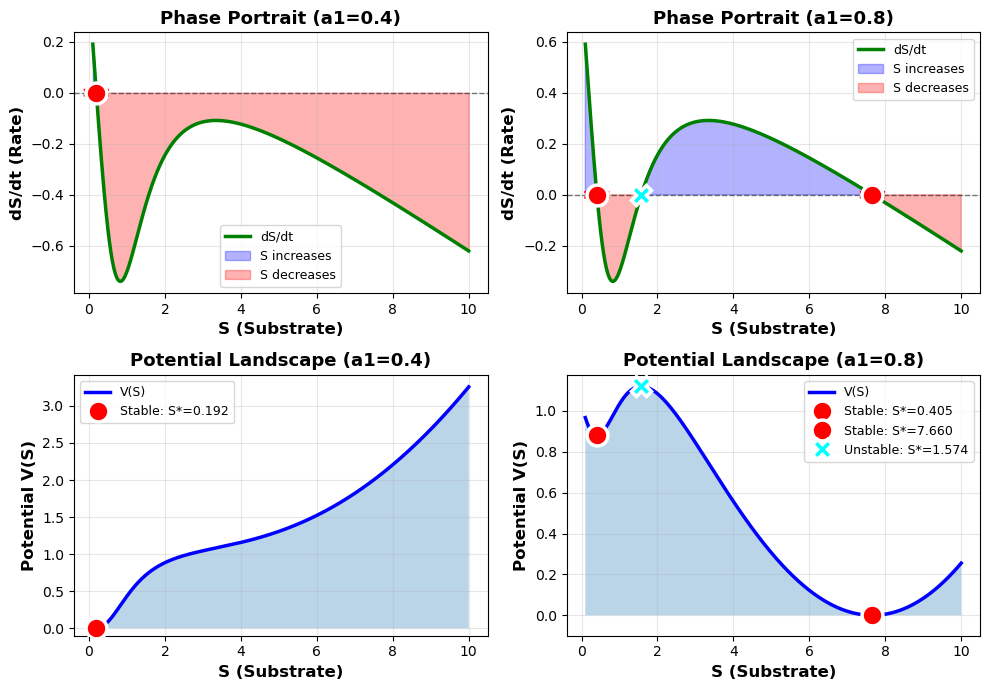

In [25]:
# Generate the phase-portrait + potential-landscape comparison for
# a1 = 0.4 (monostable, single well) and a1 = 0.8 (bistable, double well).
plot_1D_potential_comparison()

### Reading the potential landscape

The two panels in the bottom row make the difference between monostability and bistability visually obvious:

- **$a_1=0.4$ (left):** $V(S)$ has a **single well**, with its minimum at $S^*\approx0.19$. Wherever the system starts, it rolls downhill into this one valley — there is only one possible outcome.
- **$a_1=0.8$ (right):** $V(S)$ has **two wells separated by a barrier**: a shallow well at $S^*\approx0.41$ ($V\approx0.88$), a barrier (local maximum) at $S^*\approx1.57$ ($V\approx1.12$), and a deeper well — the global minimum — at $S^*\approx7.66$ ($V=0$). Now the *initial condition* (or a transient perturbation) determines which valley the system ends up in: two different starting points, on either side of the barrier, lead to two different final states.

This is the essence of multistability as a landscape phenomenon: a smooth change in a single parameter ($a_1$, going from $0.4$ to $0.8$) reshapes the landscape from "one valley" to "two valleys separated by a ridge" — without any explicit switch mechanism being added to the model. The next section makes this reshaping itself the subject of the plot, by treating $a_1$ as a continuous second axis.

### From one landscape to a family of landscapes

Each panel above is a *snapshot* of the landscape for one fixed value of $a_1$. The natural next step is to ask what happens to the landscape as $a_1$ changes *continuously* — does the single well at $a_1=0.4$ smoothly turn into the two wells seen at $a_1=0.8$, and if so, how?

To find out, we compute $V(S)$ for many values of $a_1$ and stack the resulting curves side by side, turning the 1D landscape $V(S)$ into a 2D surface $V(S, a_1)$. This is exactly the construction behind Waddington's "epigenetic landscape" — one of the most influential metaphors in developmental biology.

# Code 
## The Waddington Potential "Landscape"

In 1957, the developmental biologist Conrad Waddington introduced the **epigenetic landscape**: a picture of development as a ball rolling downhill through a landscape of branching valleys. Each valley represents a possible cell fate; the ridges separating valleys represent developmental decision points; and the overall shape of the landscape is sculpted by the underlying gene-regulatory network. For a long time this was a purely qualitative metaphor — there was no equation behind the picture.

The 1D potential $V(S)$ from the previous section gives us exactly the missing ingredient: an actual, computable potential derived from the kinetic equations of the system. The cell below takes the final step and promotes the control parameter $a_1$ to a second axis of the landscape, producing a genuine 2D "quasi-potential" surface $V(S, a_1)$ — a small, concrete, quantitative example of Waddington's picture.

### Interpreting the axes

- $S$ (substrate concentration) is the **state** of the system — the position of the "ball".
- $a_1$ plays the role of Waddington's developmental axis or a slowly changing control signal: a morphogen concentration, an upstream regulatory input, or simply time during a developmental process. Moving along this axis reshapes the landscape itself.
- $V(S, a_1)$ is the height of the landscape: the system's state rolls downhill (towards lower $V$) at fixed $a_1$, while changes in $a_1$ can raise, lower, merge, or split the valleys.

As $a_1$ increases through $\approx0.51$ (the saddle-node bifurcation found above), a single valley splits into two, separated by a ridge — visually, this is precisely Waddington's branch point where one developmental path divides into two.

### Why this matters beyond enzyme kinetics

The same picture — valleys as stable states, ridges as decision points, and a control axis that reshapes the landscape — recurs throughout biology:

- **Gene expression and bistable switches.** In a mutual-repression "toggle switch" between two genes, the two valleys correspond to "gene A high / gene B low" and "gene A low / gene B high" expression states. A transient signal (playing the role of $a_1$ here) can push the system from one valley over the ridge into the other — after which it stays there, even once the signal is removed.
- **Development and cell-fate decisions.** In stem-cell differentiation, the valleys correspond to distinct cell types, and the changing "control parameter" corresponds to developmental signals (morphogen gradients, transcription-factor levels) that reshape the landscape over time — opening new valleys (differentiation into new cell types) or, in principle, merging them again (reprogramming/dedifferentiation).
- **Biological information processing.** A multistable landscape is, functionally, a **decision element**: a graded input is converted into a discrete output (which valley the system ends up in), and that output is *remembered* — because of hysteresis — even after the input returns to its original value. Networks built from many such elements form the basis of biological switches, memory circuits, and decision-making pathways, from cell-cycle checkpoints to immune cell activation.

The cell below builds an interactive 3D version of this landscape that can be rotated and zoomed.

INTERACTIVE 'WADDINGTON' LANDSCAPE
Computing interactive Waddington landscape...

✓ Interactive plot saved to: waddington_landscape_interactive.html


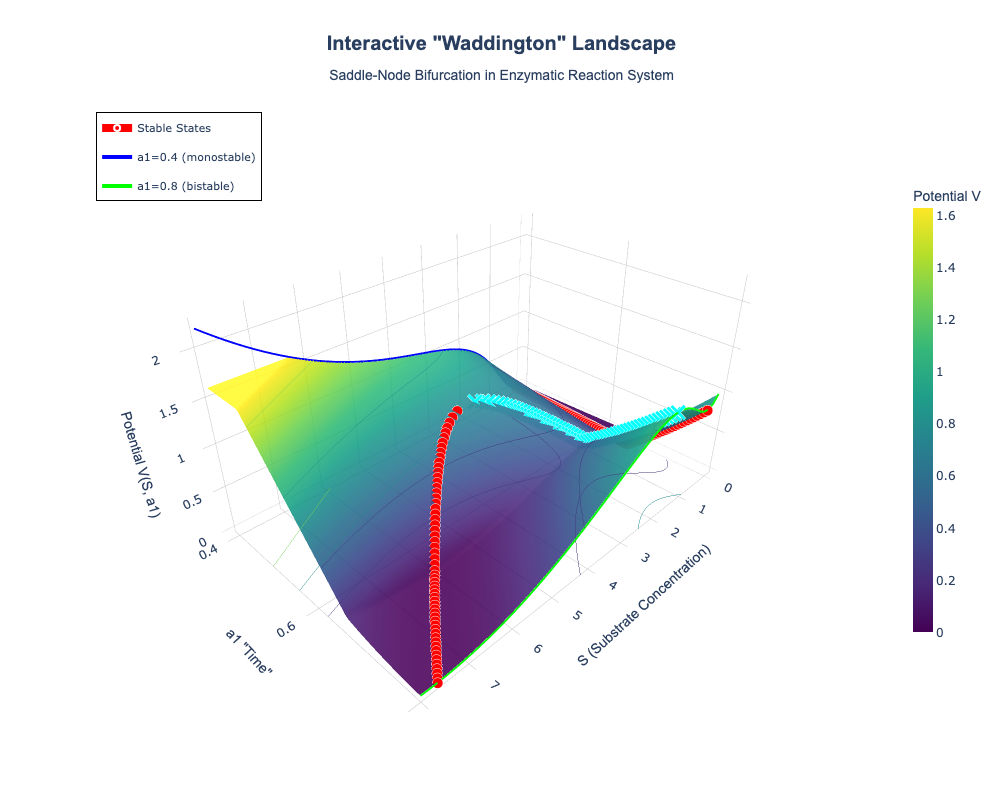


EXPORT OPTIONS:
1. Open 'waddington_landscape_interactive.html' in your browser
2. Interactive controls:
   - Rotate: Click and drag
   - Zoom: Scroll or pinch
   - Pan: Right-click and drag
   - Reset view: Double-click
3. Download static PNG using camera icon in toolbar
4. HTML file is self-contained and shareable!


In [26]:
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import fsolve
from scipy.integrate import cumulative_trapezoid

# The next four functions are the same as in the previous "Analysis of
# Bistability" section (dS_dt, find_steady_states_1D, check_stability_1D,
# compute_potential_1D) - repeated here so this cell is self-contained.
# See the markdown and comments above for the reasoning behind each one.

def dS_dt(S, a1, b1, k_max, K_m, n, m):
    """First equation only - S dynamics independent of P"""
    enzymatic_rate = (k_max * S**n) / (K_m**m + S**m)
    return a1 - b1 * S - enzymatic_rate

def find_steady_states_1D(a1, b1, k_max, K_m, n, m):
    """Find steady states for S equation (root-finding from many initial
    guesses, de-duplicated - see the detailed comments earlier in the
    notebook)."""
    steady_states = []
    for S_guess in np.linspace(0.1, 15, 50):
        try:
            sol = fsolve(lambda S: dS_dt(S, a1, b1, k_max, K_m, n, m), 
                        S_guess, full_output=True)
            if sol[2] == 1:
                S_star = sol[0][0]
                if S_star > 0:
                    residual = abs(dS_dt(S_star, a1, b1, k_max, K_m, n, m))
                    if residual < 1e-8:
                        is_new = True
                        for existing in steady_states:
                            if abs(S_star - existing) < 1e-4:
                                is_new = False
                                break
                        if is_new:
                            steady_states.append(S_star)
        except:
            pass
    
    return sorted(steady_states)

def check_stability_1D(S_star, a1, b1, k_max, K_m, n, m, epsilon=1e-6):
    """Stable if d(dS/dt)/dS < 0 at the steady state (see earlier section)."""
    f_plus = dS_dt(S_star + epsilon, a1, b1, k_max, K_m, n, m)
    f_minus = dS_dt(S_star - epsilon, a1, b1, k_max, K_m, n, m)
    derivative = (f_plus - f_minus) / (2 * epsilon)
    is_stable = derivative < 0
    return is_stable, derivative

def compute_potential_1D(a1, b1, k_max, K_m, n, m, S_range=(0.1, 10), resolution=1000):
    """Compute 1D potential V(S) such that dS/dt = -dV/dS (see earlier section)."""
    S_array = np.linspace(S_range[0], S_range[1], resolution)
    dS_dt_array = np.array([dS_dt(S, a1, b1, k_max, K_m, n, m) for S in S_array])
    potential = cumulative_trapezoid(-dS_dt_array, S_array, initial=0)
    potential = potential - np.min(potential)
    return S_array, potential, dS_dt_array

def separate_branches(S_vals, a1_vals, V_vals, stability_vals, threshold=0.5):
    """Group the (S, a1, V) steady-state points into continuous branches.

    find_steady_states_1D is called independently for each a1, so the
    resulting list of steady states is just a flat sequence of points - it
    does not yet know which points belong to the "low", "middle", or
    "high" branch, or where a branch begins/ends (at a bifurcation point).

    This function walks through the points in order and starts a new
    branch whenever either (a) the steady-state value S jumps by more than
    `threshold` from one a1 to the next, or (b) the stability flag changes.
    Both situations indicate we have crossed a bifurcation point and moved
    onto a different branch. Plotting each branch separately (rather than
    connecting all points with one line) avoids drawing spurious lines that
    jump between unrelated branches.
    """
    branches = []
    current_branch = {'S': [], 'a1': [], 'V': [], 'stable': None}
    
    for i in range(len(S_vals)):
        if i == 0:
            current_branch['S'].append(S_vals[i])
            current_branch['a1'].append(a1_vals[i])
            current_branch['V'].append(V_vals[i])
            current_branch['stable'] = stability_vals[i]
        else:
            # Check if this point is continuous with the current branch
            if (abs(S_vals[i] - S_vals[i-1]) < threshold and 
                stability_vals[i] == current_branch['stable']):
                current_branch['S'].append(S_vals[i])
                current_branch['a1'].append(a1_vals[i])
                current_branch['V'].append(V_vals[i])
            else:
                # Start a new branch
                if len(current_branch['S']) > 0:
                    branches.append(current_branch)
                current_branch = {
                    'S': [S_vals[i]], 
                    'a1': [a1_vals[i]], 
                    'V': [V_vals[i]], 
                    'stable': stability_vals[i]
                }
    
    # Don't forget the last branch
    if len(current_branch['S']) > 0:
        branches.append(current_branch)
    
    return branches

def create_interactive_waddington_landscape():
    """Build the 2D "Waddington" potential landscape V(S, a1) and display
    it as an interactive 3D Plotly surface.

    Overview of what happens below:
      1. For each value of a1 in a1_array, compute the 1D potential
         V(S; a1) (one row of the landscape) and find/classify its steady
         states.
      2. Stack all these rows into a 2D array `potential_matrix` -> this is
         the landscape surface.
      3. Group the steady states found across all a1 into continuous
         stable/unstable branches with separate_branches(), and draw them
         as red (stable) / cyan dashed (unstable) curves on top of the
         surface - this traces out the bifurcation diagram *on* the
         landscape.
      4. Add two reference curves showing the 1D cross-sections at
         a1=0.4 (monostable) and a1=0.8 (bistable), matching the panels
         plotted earlier.
    """
    # Parameters
    b1 = 0.1
    k_max, K_m = 2, 1
    n, m = 1, 3
    
    # Create arrays with high resolution
    a1_array = np.linspace(0.4, 0.8, 80)
    S_range = (0.05, 8)  # FIXED: Start from much lower value to see low steady state
    S_resolution = 500
    
    # Initialize potential matrix
    S_array = np.linspace(S_range[0], S_range[1], S_resolution)
    potential_matrix = np.zeros((len(a1_array), S_resolution))
    
    # Store steady states
    all_steady_states = []
    all_a1_for_states = []
    all_stability = []
    all_V_for_states = []
    
    print("Computing interactive Waddington landscape...")
    for i, a1 in enumerate(a1_array):
        # One "row" of the landscape: the 1D potential at this a1
        _, potential, _ = compute_potential_1D(a1, b1, k_max, K_m, n, m, 
                                               S_range, S_resolution)
        potential_matrix[i, :] = potential
        
        # Steady states (and their stability/potential value) at this a1 -
        # these will be drawn as the bifurcation curve on the landscape
        steady_states = find_steady_states_1D(a1, b1, k_max, K_m, n, m)
        for S_star in steady_states:
            is_stable, _ = check_stability_1D(S_star, a1, b1, k_max, K_m, n, m)
            V_star = np.interp(S_star, S_array, potential)
            all_steady_states.append(S_star)
            all_a1_for_states.append(a1)
            all_stability.append(is_stable)
            all_V_for_states.append(V_star)
    
    # Create meshgrid
    S_mesh, a1_mesh = np.meshgrid(S_array, a1_array)
    
    # Cap the potential for better visualization
    V_plot = potential_matrix.copy()
    V_max = np.percentile(V_plot, 98)
    V_plot = np.clip(V_plot, 0, V_max)
    
    # FIXED: Separate branches to avoid connecting discontinuous points
    branches = separate_branches(
        all_steady_states, 
        all_a1_for_states, 
        all_V_for_states, 
        all_stability,
        threshold=0.5  # Adjust this if needed
    )
    
    # Create the figure
    fig = go.Figure()
    
    # Add the main surface
    fig.add_trace(go.Surface(
        x=S_mesh,
        y=a1_mesh,
        z=V_plot,
        colorscale='Viridis',
        opacity=0.95,
        name='Potential Landscape',
        colorbar=dict(
            title=dict(
                text='Potential V',
                font=dict(size=14, family='Arial, sans-serif')
            ),
            tickfont=dict(size=12),
            len=0.75,
            thickness=20
        ),
        contours=dict(
            z=dict(
                show=True,
                usecolormap=True,
                highlightcolor="white",
                project=dict(z=True)
            )
        ),
        hovertemplate='<b>S</b>: %{x:.3f}<br><b>a1</b>: %{y:.3f}<br><b>V</b>: %{z:.3f}<extra></extra>'
    ))
    
    # FIXED: Add each branch separately as lines+markers
    for i, branch in enumerate(branches):
        if branch['stable']:
            fig.add_trace(go.Scatter3d(
                x=branch['S'],
                y=branch['a1'],
                z=branch['V'],
                mode='lines+markers',
                name=f'Stable Branch {i+1}' if i > 0 else 'Stable States',
                line=dict(color='red', width=8),
                marker=dict(
                    size=6,
                    color='red',
                    symbol='circle',
                    line=dict(color='white', width=2)
                ),
                showlegend=(i == 0),  # Only show legend for first stable branch
                legendgroup='stable',
                hovertemplate='<b>Stable State</b><br>S: %{x:.4f}<br>a1: %{y:.4f}<br>V: %{z:.4f}<extra></extra>'
            ))
        else:
            fig.add_trace(go.Scatter3d(
                x=branch['S'],
                y=branch['a1'],
                z=branch['V'],
                mode='lines+markers',
                name=f'Unstable Branch {i+1}' if i > 0 else 'Unstable States',
                line=dict(color='cyan', width=8, dash='dash'),
                marker=dict(
                    size=4,
                    color='cyan',
                    symbol='x',
                    line=dict(color='white', width=2)
                ),
                showlegend=(i == 0),  # Only show legend for first unstable branch
                legendgroup='unstable',
                hovertemplate='<b>Unstable State</b><br>S: %{x:.4f}<br>a1: %{y:.4f}<br>V: %{z:.4f}<extra></extra>'
            ))
    
    # Add reference planes
    idx_04 = np.argmin(np.abs(a1_array - 0.4))
    S_plane = np.linspace(S_range[0], S_range[1], 50)
    a1_plane_04 = np.full_like(S_plane, 0.4)
    V_plane_04 = np.interp(S_plane, S_array, potential_matrix[idx_04, :])
    
    fig.add_trace(go.Scatter3d(
        x=S_plane,
        y=a1_plane_04,
        z=V_plane_04,
        mode='lines',
        name='a1=0.4 (monostable)',
        line=dict(color='blue', width=4),
        hovertemplate='<b>a1=0.4</b><br>S: %{x:.3f}<br>V: %{z:.3f}<extra></extra>'
    ))
    
    idx_06 = np.argmin(np.abs(a1_array - 0.8))
    a1_plane_06 = np.full_like(S_plane, 0.8)
    V_plane_06 = np.interp(S_plane, S_array, potential_matrix[idx_06, :])
    
    fig.add_trace(go.Scatter3d(
        x=S_plane,
        y=a1_plane_06,
        z=V_plane_06,
        mode='lines',
        name='a1=0.8 (bistable)',
        line=dict(color='lime', width=4),
        hovertemplate='<b>a1=0.8</b><br>S: %{x:.3f}<br>V: %{z:.3f}<extra></extra>'
    ))
    
    # Update layout
    fig.update_layout(
        title=dict(
            text='<b>Interactive "Waddington" Landscape</b><br>' +
                 '<sub>Saddle-Node Bifurcation in Enzymatic Reaction System</sub>',
            x=0.5,
            xanchor='center',
            font=dict(size=20, family='Arial, sans-serif')
        ),
        scene=dict(
            xaxis=dict(
                title=dict(text='S (Substrate Concentration)', 
                          font=dict(size=14, family='Arial, sans-serif')),
                gridcolor='lightgray',
                showbackground=True,
                backgroundcolor='rgba(230, 230, 230, 0.5)'
            ),
            yaxis=dict(
                title=dict(text='a1 "Time"', 
                          font=dict(size=14, family='Arial, sans-serif')),
                gridcolor='lightgray',
                showbackground=True,
                backgroundcolor='rgba(230, 230, 230, 0.5)'
            ),
            zaxis=dict(
                title=dict(text='Potential V(S, a1)', 
                          font=dict(size=14, family='Arial, sans-serif')),
                gridcolor='lightgray',
                showbackground=True,
                backgroundcolor='rgba(230, 230, 230, 0.5)'
            ),
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.3),
                center=dict(x=0, y=0, z=0)
            ),
            aspectmode='manual',
            aspectratio=dict(x=1.5, y=1, z=0.8)
        ),
        width=1200,
        height=800,
        showlegend=True,
        legend=dict(
            x=0.02,
            y=0.98,
            bgcolor='rgba(255, 255, 255, 0.8)',
            bordercolor='black',
            borderwidth=1,
            font=dict(size=11)
        ),
        hovermode='closest',
        template='plotly_white'
    )
    
    # Save to HTML
    html_file = 'waddington_landscape_interactive.html'
    fig.write_html(html_file)
    print(f"\n✓ Interactive plot saved to: {html_file}")
    
    # Show the plot
    fig.show()
    
    return fig

# Run the interactive Plotly analysis
print("="*60)
print("INTERACTIVE 'WADDINGTON' LANDSCAPE")
print("="*60)
fig1 = create_interactive_waddington_landscape()
print("\n" + "="*60)
print("EXPORT OPTIONS:")
print("="*60)
print("1. Open 'waddington_landscape_interactive.html' in your browser")
print("2. Interactive controls:")
print("   - Rotate: Click and drag")
print("   - Zoom: Scroll or pinch")
print("   - Pan: Right-click and drag")
print("   - Reset view: Double-click")
print("3. Download static PNG using camera icon in toolbar")
print("4. HTML file is self-contained and shareable!")
print("="*60)

## Summary and outlook

This notebook started from the same ingredient as notebook *03_enzyme_oscillations* — a Hill-type enzymatic rate law with forward (substrate) inhibition — but followed it down a different path:

- Embedding the nonlinear rate law in an open-flow system (constant influx, linear removal) and reducing to a single ODE for $S$ gave an equation whose steady states could be found and classified analytically/numerically.
- For a range of the input parameter $a_1$ (roughly $0.51$ to $1.15$ in our numerical example), this equation has **three** steady states: two stable and one unstable — i.e. the system is **bistable**.
- Rewriting the equation as $dS/dt = -dV/dS$ turned this steady-state structure into a **potential landscape** $V(S)$: stable states are valleys, the unstable state is the barrier between them.
- Letting $a_1$ vary continuously turned the 1D landscape into a 2D surface $V(S, a_1)$ that visually reproduces **Waddington's epigenetic landscape**: a single valley splitting into two as a control parameter crosses a bifurcation point.

**Outlook.** Because this notebook's reduced model is a *single* ODE, the only possible long-term behaviours are steady states (stable or unstable) — oscillations are impossible in one dimension. Notebook *03_enzyme_oscillations* reintroduces the second variable (the product $P$) and replaces forward inhibition with *delayed, feedback* inhibition. With two coupled variables, a steady state can lose stability through a different route (a Hopf bifurcation), turning into an unstable spiral surrounded by a stable limit cycle — sustained oscillations. Multistability and oscillations are therefore best thought of as two outcomes of the same underlying nonlinear dynamics, reached by slightly different routes.

## References and further reading

- Waddington, C.H. (1957). *The Strategy of the Genes*. George Allen & Unwin. — the original source of the "epigenetic landscape" metaphor used throughout this notebook.
- Ferrell, J.E. (2012). Bistability, bifurcations, and Waddington's epigenetic landscape. *Current Biology*, 22(11), R458–R466. — a modern, quantitative treatment connecting bistability and bifurcation theory directly to Waddington's picture.
- Gardner, T.S., Cantor, C.R., Collins, J.J. (2000). Construction of a genetic toggle switch in *Escherichia coli*. *Nature*, 403, 339–342. — an experimental realisation of a bistable gene-regulatory switch, the genetic analogue of the two-valley landscape above.
- Tyson, J.J., Chen, K.C., Novak, B. (2003). Sniffers, buzzers, toggles and blinkers: dynamics of regulatory and signaling pathways in the cell. *Current Opinion in Cell Biology*, 15(2), 221–231. — reviews recurring dynamical "modules" in cell regulation, including toggle switches (bistability, this notebook) and blinkers/oscillators (notebook *03_enzyme_oscillations*). Available as a PDF in this folder.
- Wang, J., Zhang, K., Xu, L., Wang, E. (2011). Quantifying the Waddington landscape and biological paths for development and differentiation. *Proceedings of the National Academy of Sciences*, 108(20), 8257–8262. — a quantitative landscape approach applied to stem-cell differentiation, in the same spirit as the 2D landscape built in this notebook.

# Appendix: Bifurcation diagram of the Hill function


In [27]:
def hill_open_model(variables, time, parameters):
    
    S, P = variables[0], variables[1]
    
    k_max, K_m, n      = parameters[0], parameters[1], parameters[2]
    a_s, a_p, b_s, b_p = parameters[3], parameters[4], parameters[5], parameters[5]

    rate = k_max*S**n/(K_m + S**n)
    
    dS_dt  = a_s - b_s*S - rate
    dP_dt  = a_p - b_p*P + rate
    
    return [dS_dt, dP_dt]

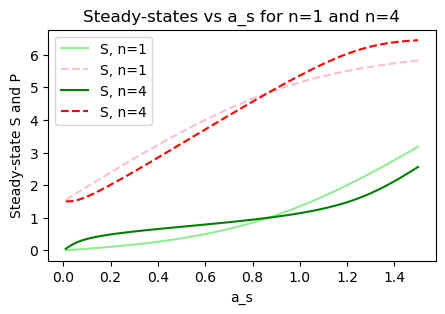

In [28]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# Bifurcation (steady-state response) diagram: scan a_s, compare n=1 vs n=4
#
# Note: in this model dS/dt = a_s - b_s*S - rate(S) is strictly decreasing in S
# (both b_s*S and rate(S) only increase with S), so there is exactly ONE stable
# steady state for any a_s -- no multistability or hysteresis is possible here.
# What changes with n is how SHARP/switch-like that steady-state curve is.

n_values = [1, 4]
colors   = [('lightgreen', 'green'), ('pink', 'red')]

a_s_values = np.linspace(0.01, 1.5, 60)

# Fixed parameters (same as the time-series cell above)
# k_max, K_m, a_p, b_s, b_p
k_max, K_m, a_p, b_s, b_p = 1, 0.5, 0.3, 0.2, 0.4

# Time range to relax to steady state for each a_s
t_start, t_stop, time_step = 0, 100, 0.1
time = np.arange(t_start, t_stop, time_step)

fig, ax = plt.subplots(figsize=(5, 3))

for index, n in enumerate(n_values):

    # Forward sweep: a_s increasing, continuing from the previous steady state
    S_forward = []
    P_forward = []
    variables_init = [0, 0]
    for a_s in a_s_values:
        parameters = [k_max, K_m, n, a_s, a_p, b_s, b_p]
        variables  = odeint(hill_open_model, variables_init, time, args=(parameters,))
        variables_init = variables[-1]
        S_forward.append(variables_init[0])
        P_forward.append(variables_init[1])

    ax.plot(a_s_values, S_forward,  '-',  c=colors[0][index], label=f'S, n={n}')
    ax.plot(a_s_values, P_forward, '--', c=colors[1][index], label=f'S, n={n}')

ax.set_xlabel('a_s')
ax.set_ylabel('Steady-state S and P')
ax.set_title('Steady-states vs a_s for n=1 and n=4')
ax.legend(loc='best');
# fig.show()

#plt.savefig('hill_bifurcation_diagram.png')

The steady state (stable) concentrations are a balance between input, removals, and nonlinear reaction term.